In [85]:
import pandas as pd
# Load the dataset
df_data = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")

df_data


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_count_A,CDR_H1_count_R,CDR_H1_count_N,CDR_H1_count_D,CDR_H1_count_C,...,CDR_H2_mean_polarity,CDR_H2_mean_mass,CDR_H3_mean_hydrophobicity,CDR_H3_mean_charge,CDR_H3_mean_polarity,CDR_H3_mean_mass,cdr_h1_length,cdr_h2_length,cdr_h3_length,source
0,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,9.920000,153.744000,0.737500,0.000000,7.875000,129.018750,9,5,8,human
1,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,9.920000,153.744000,0.737500,0.000000,7.875000,129.018750,9,5,8,human
2,8znz,F,AIYYYGSSYNYYAMDY,SSGGGY,GFTFSKY,0.0,0.0,0.0,0.0,0.0,...,8.600000,102.763333,-0.506250,-0.062500,7.656250,142.335000,7,6,16,human
3,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,7.466667,139.810000,-0.275000,-0.125000,7.725000,133.763750,7,6,8,human
4,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,7.466667,139.810000,-0.275000,-0.125000,7.725000,133.763750,7,6,8,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN,0.0,0.0,1.0,0.0,0.0,...,8.520000,108.302000,-0.855556,-0.222222,9.411111,131.915556,7,5,9,sars_cov2
957,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY,0.0,0.0,0.0,0.0,0.0,...,9.733333,123.780000,-0.250000,-0.166667,8.158333,129.798333,7,6,12,sars_cov2
958,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS,0.0,0.0,0.0,0.0,0.0,...,8.316667,105.945000,0.042857,-0.142857,8.214286,125.343571,7,6,14,sars_cov2
959,7n3d,H,HSRIEVAGTLDFDY,YYSGN,GGSISSY,0.0,0.0,0.0,0.0,0.0,...,8.440000,134.932000,-0.307143,-0.071429,8.678571,132.637857,7,5,14,sars_cov2


In [86]:
CDR_H3_sequences = df_data["CDR_H3"].tolist() # spalte CDR_H3 als liste
CDR_H2_sequences = df_data["CDR_H2"].tolist() # spalte CDR_H2 als liste
CDR_H1_sequences = df_data["CDR_H1"].tolist() # spalte CDR_H1 als liste
CDR=0 # CDR_H1_sequences # CDR_H1 als default CDR
df_data.head()
extra_data_names = df_data.columns.tolist()[5:17] # spaltennamen als liste, ab so hydophobicity und so
extracted_data = df_data[extra_data_names].values.T # transformierte matrix, d.h. die einzelnen pdbs sind jetzt spalten (der reihenfolge nach), statt zeilen
print("Extracted data shape:", extracted_data.shape)
print("feature 1:", extra_data_names[0],extracted_data[0].shape)

df_data

Extracted data shape: (12, 961)
feature 1: CDR_H1_count_A (961,)


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_count_A,CDR_H1_count_R,CDR_H1_count_N,CDR_H1_count_D,CDR_H1_count_C,...,CDR_H2_mean_polarity,CDR_H2_mean_mass,CDR_H3_mean_hydrophobicity,CDR_H3_mean_charge,CDR_H3_mean_polarity,CDR_H3_mean_mass,cdr_h1_length,cdr_h2_length,cdr_h3_length,source
0,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,9.920000,153.744000,0.737500,0.000000,7.875000,129.018750,9,5,8,human
1,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,9.920000,153.744000,0.737500,0.000000,7.875000,129.018750,9,5,8,human
2,8znz,F,AIYYYGSSYNYYAMDY,SSGGGY,GFTFSKY,0.0,0.0,0.0,0.0,0.0,...,8.600000,102.763333,-0.506250,-0.062500,7.656250,142.335000,7,6,16,human
3,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,7.466667,139.810000,-0.275000,-0.125000,7.725000,133.763750,7,6,8,human
4,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,7.466667,139.810000,-0.275000,-0.125000,7.725000,133.763750,7,6,8,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN,0.0,0.0,1.0,0.0,0.0,...,8.520000,108.302000,-0.855556,-0.222222,9.411111,131.915556,7,5,9,sars_cov2
957,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY,0.0,0.0,0.0,0.0,0.0,...,9.733333,123.780000,-0.250000,-0.166667,8.158333,129.798333,7,6,12,sars_cov2
958,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS,0.0,0.0,0.0,0.0,0.0,...,8.316667,105.945000,0.042857,-0.142857,8.214286,125.343571,7,6,14,sars_cov2
959,7n3d,H,HSRIEVAGTLDFDY,YYSGN,GGSISSY,0.0,0.0,0.0,0.0,0.0,...,8.440000,134.932000,-0.307143,-0.071429,8.678571,132.637857,7,5,14,sars_cov2


In [87]:
print("First 5 CDR_H3 Sequences:", CDR_H3_sequences[:5])  # Print first 5 sequences
# max length of cdr sequences (for array), ignore non-string (e.g. float) entries
max_length_h3 = max(len(seq) for seq in CDR_H3_sequences if isinstance(seq, str))
max_length_h2 = max(len(seq) for seq in CDR_H2_sequences if isinstance(seq, str))
max_length_h1 = max(len(seq) for seq in CDR_H1_sequences if isinstance(seq, str))
print("Max length of CDR_H3 sequences:", max_length_h3) #cdrh3 haben die längsten cdr sequenzen
print("number of CDR_H3 sequences:", len(CDR_H3_sequences))
print("number OF CDR_H2 sequences:", len(CDR_H2_sequences))
print("number of CDR_H1 sequences:", len(CDR_H1_sequences))

First 5 CDR_H3 Sequences: ['RFVGTLDV', 'RFVGTLDV', 'AIYYYGSSYNYYAMDY', 'GYGWALDY', 'GYGWALDY']
Max length of CDR_H3 sequences: 26
number of CDR_H3 sequences: 961
number OF CDR_H2 sequences: 961
number of CDR_H1 sequences: 961


In [88]:
# feature matrix um sequenzen einheitlich als vektoren darzustellen
import numpy as np

# Function um eine sequence in eine numerische Darstellung umzuwandeln
def onehot_of_sequence(seq, aa_list,length:int = None):
    if length is None:
        length = len(seq)
    aa_to_idx = {aa: i for i, aa in enumerate(aa_list)} # erzeugt dictionary
    onehot = np.zeros((length, len(aa_list)), dtype=int) # erzeugt matrix mit nullen (26x21)
    for i, aa in enumerate(seq): # für jede AS in der sequenz, wird an der passenden stelle eine 1 gesetzt
        idx = aa_to_idx.get(aa, aa_to_idx["-"])  # Handle unknown amino acids
        onehot[i, idx] = 1
    onehot = onehot.flatten()  # verwandelt matrix in vektor
    return onehot

#beispiel
example_embedding = onehot_of_sequence("CASSLGTGQYF", "ACDEFGHIKLMNPQRSTVWY-",length=26) # weil max länge 26 ist
print("onehot_of_sequence:", example_embedding, "shape:", example_embedding.shape)

print("onehot_of_sequence:", example_embedding, "shape:", example_embedding.shape)


onehot_of_sequence: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 

In [89]:
def embedding_of_CDRs(CDRs=["H3"], aa_list = "ACDEFGHIKLMNPQRSTVWY-"): # definiere eine funktion die
    """    Erzeugt ein Embedding für die angegebenen CDRs aus dem DataFrame df_data.
    Args:
        CDRs (list): Liste der CDRs, für die das Embedding erstellt werden soll.
        aa_list (str): Liste der Aminosäuren, die in den Sequenzen vorkommen können.
    Returns:
        np.ndarray: Ein 2D-Array, das die Embeddings für die angegebenen CDRs enthält.
    """
    #load the dataframe
    df_data = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")
    n_data = len(df_data[f"CDR_{CDRs[0]}"].tolist()) # Anzahl der Sequenzen in CDR_H3
    embedding = np.zeros((n_data, 1),dtype=float) #leeres numpy array als "Platzhalter"
    for CDR in CDRs:
        for i, seq in enumerate(df_data[f"CDR_{CDR}"].tolist()): # für jede sequenz in der spalte
            if isinstance(seq, str):  # sicherstellen, dass es sich um eine Zeichenkette handelt
                embedding[i] = onehot_of_sequence(seq, aa_list,length=max_length_h3) # speichere das embedding in der matrix
            else:
                embedding[i] = np.zeros(len(aa_list) * max_length_h3)  # Fülle mit Nullen, wenn keine Sequenz vorhanden ist
    
    return embedding
embedding = embedding_of_CDRs(["H3", "H2", "H1"])
print("Embedding shape:", embedding.shape)  # sollte (n_data, 26*21) sein, wenn max_length_h3=26 und aa_list 21 AS enthält



ValueError: could not broadcast input array from shape (546,) into shape (1,)

In [ ]:
embedding=embedding_of_CDRs(["H3","H2","H1"])

In [90]:
df_data

# kannst du basierend auf dem df_data eine logistische Regression machen, die vorhersagt, ob eine sequenz zu einer bestimmten gruppe gehört oder nicht? human, corona oder influenza?
from sklearn.linear_model import LogisticRegression
# Define the target variable based on the 'source' column in df_data (e.g., classify sars_cov2 vs others)
target = (df_data['source'] == 'sars_cov2').astype(int).values  # 1 if sars_cov2, else 0

# Create a logistic regression model
model = LogisticRegression(max_iter=1000)  # Increase max_iter if convergence issues occur
# Fit the model using the embedding as features
model.fit(embedding, target)
# Predict probabilities for each class
predicted_probabilities = model.predict_proba(embedding)
# Print the predicted probabilities for the first 5 samples
print("Predicted probabilities for the first 5 samples:")
print(predicted_probabilities[:5])  # Display probabilities for the first 5 samples
# Evaluate the model's accuracy
from sklearn.metrics import accuracy_score
# Predict the class labels
predicted_labels = model.predict(embedding)
# Calculate accuracy
accuracy = accuracy_score(target, predicted_labels)

NameError: name 'embedding' is not defined

In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# DataFrame laden (du hast ihn bereits)
df = df_data  # Verwende das bereits geladene DataFrame

# Features: alle Spalten mit Aminosäurehäufigkeiten (z. B. CDR_H1_count_A, ...)
aa_columns = [col for col in df.columns if "_count_" in col and any(aa in col for aa in "ACDEFGHIKLMNPQRSTVWY")]

X = df[aa_columns]
y = df["source"]  # Zielvariable

# Fehlende Werte imputieren
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()
X_imputed = imputer.fit_transform(X)

# Optional: Standardisieren (nicht immer nötig bei Häufigkeiten, aber sauber)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Modell erstellen und trainieren, trainiere mit 700 Sequenzen
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [92]:
print("✅ Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

print("🧩 Konfusionsmatrix:")
print(confusion_matrix(y_test, y_pred))

# accuracy of the model
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)


✅ Klassifikationsbericht:
              precision    recall  f1-score   support

       human       0.69      0.76      0.72        79
   influenza       0.47      0.35      0.40        20
   sars_cov2       0.70      0.68      0.69        94

    accuracy                           0.68       193
   macro avg       0.62      0.60      0.60       193
weighted avg       0.67      0.68      0.67       193

🧩 Konfusionsmatrix:
[[60  3 16]
 [ 2  7 11]
 [25  5 64]]
Accuracy: 0.6787564766839378


In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# DataFrame laden
df = df_data  # Dein vorhandener DataFrame

# Feature-Auswahl: alle Spalten mit Aminosäurezählungen
aa_columns = [col for col in df.columns if "_count_" in col and any(aa in col for aa in "ACDEFGHIKLMNPQRSTVWY")]
X = df[aa_columns]
y = df["source"]

# Fehlende Werte imputieren
imputer = SimpleImputer()
X_imputed = imputer.fit_transform(X)

# Standardisieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train/Test-Split: genau 600 für Training von dataframe df_data
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, train_size=600, stratify=y, random_state=42
)

# Modell trainieren
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# Vorhersage
y_pred = model.predict(X_test)

print("✅ Klassifikationsbericht:")
print(classification_report(y_test, y_pred))

print("🧩 Konfusionsmatrix:")
print(confusion_matrix(y_test, y_pred))

# accuracy of the model
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

✅ Klassifikationsbericht:
              precision    recall  f1-score   support

       human       0.65      0.67      0.66       149
   influenza       0.50      0.30      0.37        37
   sars_cov2       0.65      0.69      0.67       175

    accuracy                           0.64       361
   macro avg       0.60      0.55      0.57       361
weighted avg       0.64      0.64      0.64       361

🧩 Konfusionsmatrix:
[[100   3  46]
 [  8  11  18]
 [ 46   8 121]]
Accuracy: 0.6426592797783933


C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# DataFrame laden
df = df_data  # dein bestehender DataFrame

# Feature-Spalten auswählen
aa_columns = [col for col in df.columns if "_count_" in col and any(aa in col for aa in "ACDEFGHIKLMNPQRSTVWY")]
X = df[aa_columns]
y = df["source"]

# Fehlende Werte imputieren
imputer = SimpleImputer()
X_imputed = imputer.fit_transform(X)

# Standardisieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Daten aufteilen: 700 zufällig ausgewählte für Training, Rest für Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, train_size=700, stratify=y, random_state=42, shuffle=True
)

# Modell erstellen und trainieren
model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# Vorhersagen erzeugen
y_pred = model.predict(X_test)

# Ergebnisse anzeigen
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[73  1 33]
 [ 3  8 16]
 [28  5 94]]
              precision    recall  f1-score   support

       human       0.70      0.68      0.69       107
   influenza       0.57      0.30      0.39        27
   sars_cov2       0.66      0.74      0.70       127

    accuracy                           0.67       261
   macro avg       0.64      0.57      0.59       261
weighted avg       0.67      0.67      0.66       261



C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


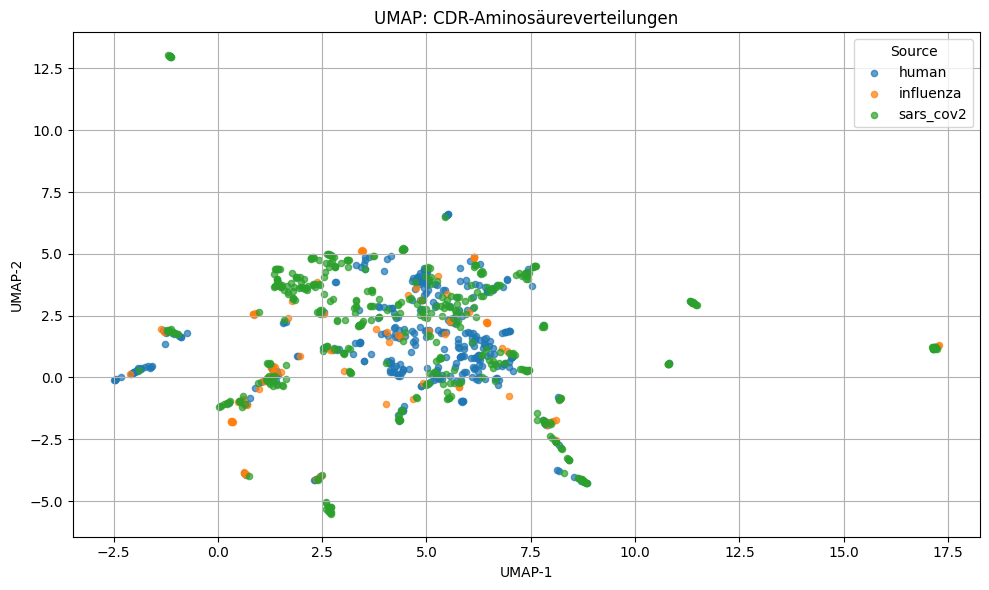

In [95]:
import umap
import matplotlib.pyplot as plt

# Reduziere auf 2D mit UMAP
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)  # oder X statt X_scaled

# Plot
plt.figure(figsize=(10, 6))
for label in sorted(y.unique()):
    idx = y == label
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.7, s=20)

plt.title("UMAP: CDR-Aminosäureverteilungen")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="Source")
plt.grid(True)
plt.tight_layout()
plt.show()


In [96]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA mit 2 Hauptkomponenten
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  # oder X, falls du nicht skaliert hast

# Erklärte Varianz
print(f"✅ PCA erklärt:")
print(f"  ➤ PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  ➤ PC2: {pca.explained_variance_ratio_[1]:.2%}")


✅ PCA erklärt:
  ➤ PC1: 5.65%
  ➤ PC2: 4.16%


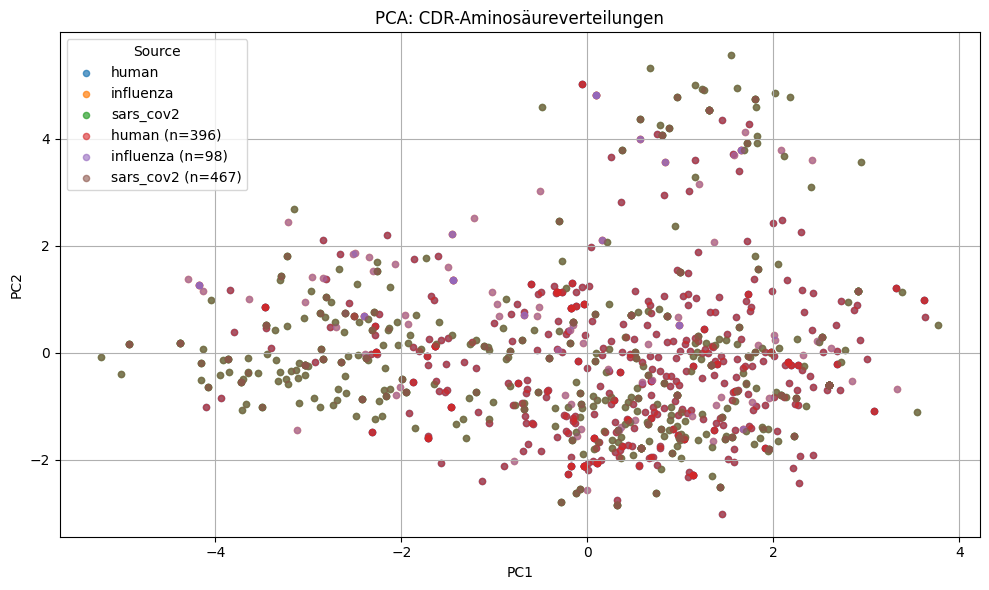

In [97]:
plt.figure(figsize=(10, 6))

# Farben nach Quelle
for label in sorted(y.unique()):
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, s=20, alpha=0.7)

for group in y.unique():
    idx = y == group
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"{group} (n={idx.sum()})", s=20, alpha=0.6)

plt.title("PCA: CDR-Aminosäureverteilungen")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Source")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print((y == "sars_cov2").sum())  # oder: print(df[df["source"] == "sars_cov2"].shape[0])


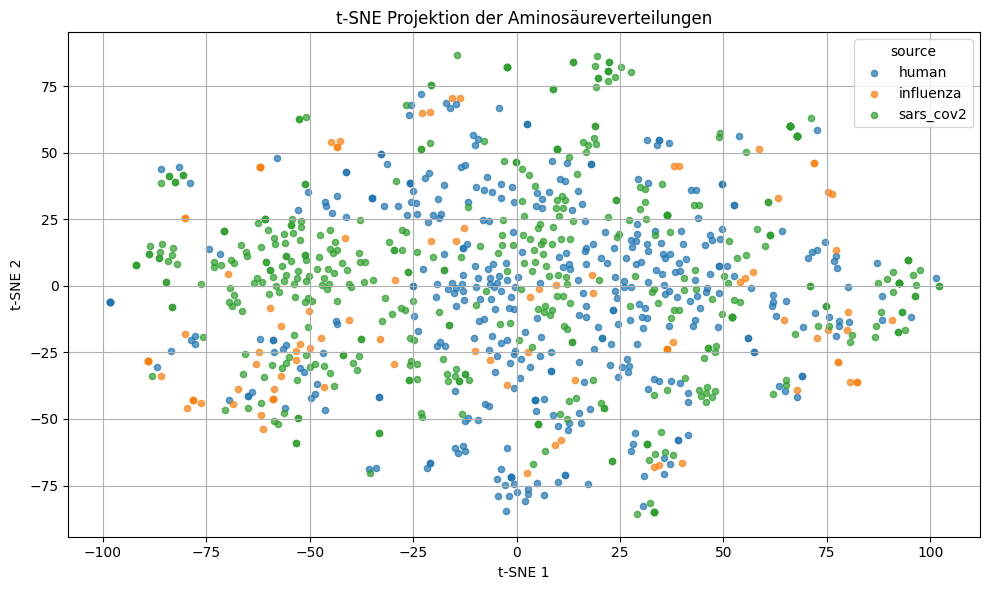

In [98]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduktion auf 2D mit t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)  # oder dein Feature-Matrix

# Plotten
plt.figure(figsize=(10, 6))
for label in y.unique():
    idx = y == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.7, s=20)

plt.title("t-SNE Projektion der Aminosäureverteilungen")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="source")
plt.grid(True)
plt.tight_layout()
plt.show()
